In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# ==========================================
# 1. Read and preprocess data
# ==========================================
print("Loading data...")
df = pd.read_csv('wifi_data_v4_final.csv')

df['true_sample_id'] = (df[['sample_id', 'location']] != df[['sample_id', 'location']].shift()).any(axis=1).cumsum()

pivot_df = df.pivot_table(
    index=['true_sample_id', 'location'],
    columns='bssid',
    values='avg_rssi'
)


# Fill missing signals with -100
pivot_df = pivot_df.fillna(-100)
final_df = pivot_df.reset_index()

final_df = final_df.rename(columns={'true_sample_id': 'sample_id'})


Loading data...


In [3]:
# ==========================================
# Data Exploration
# ==========================================
total_samples = len(final_df)
print(f"\nData exploration completed: A total of {total_samples} location samples were collected!")

print("Number of samples for each room/location:")
# value_counts() automatically counts the number of samples
# for each location and sorts them in descending order
print(final_df['location'].value_counts())
print("-" * 40 + "\n")


Data exploration completed: A total of 1957 location samples were collected!
Number of samples for each room/location:
location
MSMX 0002        40
MSMX 0003        40
MSMX 0004        40
MSMX 2001        40
MSMX 2003        40
MSMX 2004        40
MSMX 2005        40
MSMX 2006        40
MSMX 2007        40
MSMR 2009        40
MSMR 2010        40
MSMR 2011        40
MSMR 2012        40
MSMR 2014        40
MSMR 2013        40
MSMR 2015        40
MSMR 2016        40
2_Mid_Stair      40
MSMX 3001        40
MSMX 3002        40
MSMX 3003        40
MSMX 3004        40
MSMR 3005        40
MSMR 3006        40
MSMR 3009        40
MSMR 3010        40
MSMR 3011        40
MSMR 3012        40
MSMR 3013        40
MSMR 3014        40
MSMR 3015        40
MSMR 3016        40
2_Lift_Toilet    40
G_Right_Stair    40
2_Right_Stair    40
1_Right_Stair    40
1_Mid_Stair      40
1_Left_Stair     40
1_Lift_Toilet    40
G_Left_Stair     40
G_Mid_Stair      40
MSMR 3008        40
G_Lift_Toilet    40
2_Left_Stai

In [4]:
# ==========================================
# 2. Prepare features (X) and labels (y)
# ==========================================
X = final_df.drop(['sample_id', 'location'], axis=1)
y = final_df['location']

# ==========================================
# 3. Split training and testing datasets
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [5]:
# ==========================================
# 4. Train Random Forest model
# ==========================================
print("Training Random Forest model...")
# n_estimators=100 means we build 100 decision trees
# to vote for the final prediction
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

Training Random Forest model...


RandomForestClassifier(random_state=42)

In [6]:
# ==========================================
# 5. Prediction and evaluation
# ==========================================
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTesting completed! Random Forest accuracy: {accuracy * 100:.2f}%\n")

print("Detailed Classification Report:")
# zero_division=0 prevents warnings if a class is not predicted
report = classification_report(y_test, y_pred, zero_division=0)
print(report)



Testing completed! Random Forest accuracy: 91.07%

Detailed Classification Report:
               precision    recall  f1-score   support

 1_Left_Stair       1.00      1.00      1.00         8
1_Lift_Toilet       1.00      1.00      1.00         8
  1_Mid_Stair       1.00      1.00      1.00         8
1_Right_Stair       1.00      1.00      1.00         8
 2_Left_Stair       1.00      1.00      1.00         8
2_Lift_Toilet       1.00      1.00      1.00         8
  2_Mid_Stair       1.00      1.00      1.00         8
2_Right_Stair       1.00      1.00      1.00         8
 G_Left_Stair       1.00      1.00      1.00         8
G_Lift_Toilet       0.80      1.00      0.89         8
  G_Mid_Stair       1.00      0.62      0.77         8
 G_Mid_Toilet       1.00      0.75      0.86         8
G_Right_Stair       1.00      0.62      0.77         8
    MSMR 2009       1.00      0.50      0.67         8
    MSMR 2010       0.80      0.50      0.62         8
    MSMR 2011       0.67      1.00 

Generating and saving RF confusion matrix...
Confusion matrix saved as 'RF_Confusion_Matrix3.png'!


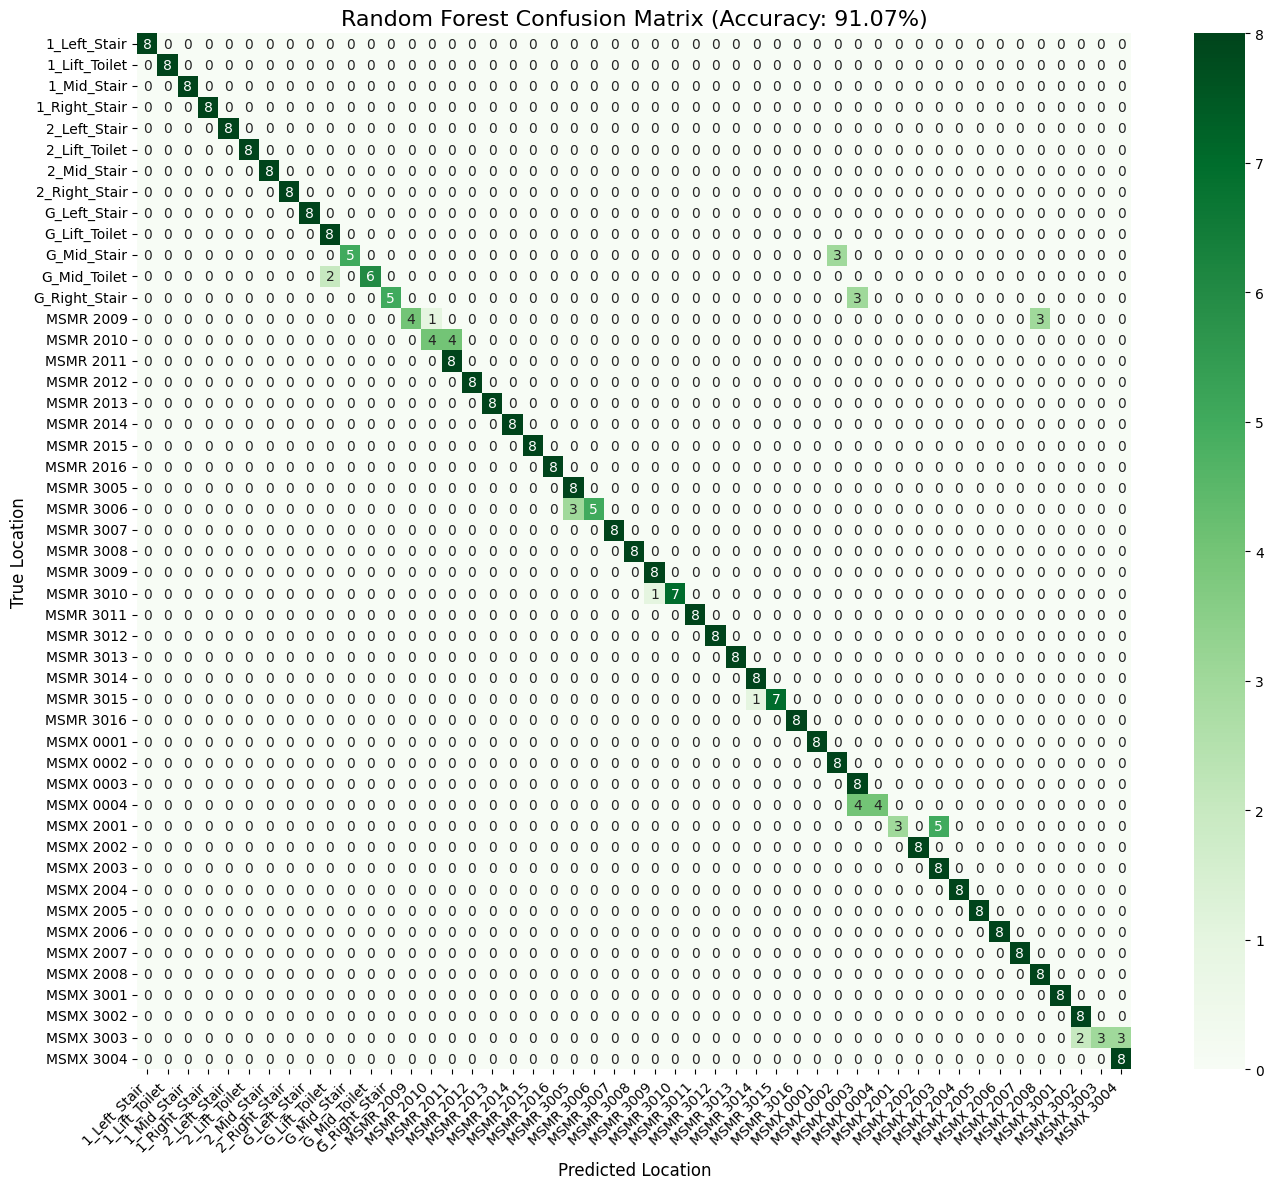

In [7]:
# ==========================================
# 6. Generate confusion matrix
# ==========================================
print("Generating and saving RF confusion matrix...")
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)

plt.figure(figsize=(14, 12))

# Use green theme to represent the forest
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)

plt.title(f'Random Forest Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)', fontsize=16)
plt.ylabel('True Location', fontsize=12)
plt.xlabel('Predicted Location', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.savefig('RF_Confusion_Matrix.png', dpi=300)

print("Confusion matrix saved as 'RF_Confusion_Matrix3.png'!")

In [8]:
import joblib

# 1. 保存你训练好的最强 AI 大脑
joblib.dump(rf, 'pwise_rf_model3.pkl')
print("Model save to 'pwise_rf_model2.pkl'")

Model save to 'pwise_rf_model2.pkl'


In [11]:
print(f"There are a total of {len(X.columns)} unique Wi-Fi routers in my building!")

There are a total of 568 unique Wi-Fi routers in my building!
